In [ ]:
import math

In [36]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __add__(self, other):
        sum = self.data + other.data
        return Value(sum, (self, other), "+")
    
    def __mul__(self, other):
        prod = self.data * other.data
        return Value(prod, (self, other), "*")
    def __repr__(self):
        return f"Value({self.data})"
    def tanh(self):
        x = self.data
        common = math.exp(2*x)
        return Value((common - 1)/(common + 1), (self, ), 'tanh')

In [42]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.2f | grad %.2f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

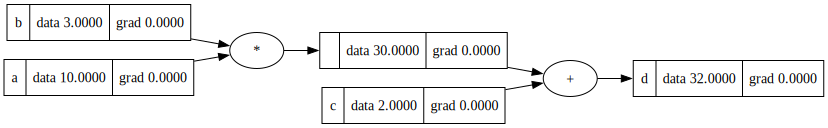

In [38]:
a = Value(10)
a.label="a"

b = Value(3)
b.label="b"

c = Value(2.0)
c.label="c"

d = (a*b)+c
d.label = "d"

draw_dot(d)

In [46]:
import math

class Neuron:
    def __init__(self, weights=None, inputs=None, bias=Value(1.0)):
        weights = weights if weights is not None else []
        inputs = inputs if inputs is not None else []
        
        self.weights = weights
        self.inputs = inputs
        self.bias = bias
    
    def set_inputs(self, inputs=None):
        if inputs is None:
            inputs = []
        
        if len(self.weights) != len(inputs):
            return
        
        self.inputs = [Value(val) for val in inputs]
    
    def calc(self):
        if len(self.inputs) == 0:
            return None
        
        x = self.bias
        for i, input_val in enumerate(self.inputs):
            print(self.weights[i])
            prod = input_val * self.weights[i]
            x += prod

        return x.tanh()

Value(1)
Value(2)


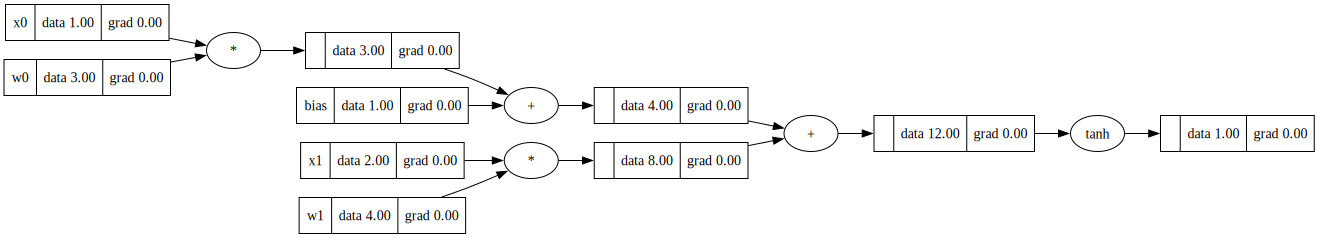

In [49]:
x0 = Value(1)
x0.label = "x0"
w0 = Value(3)
w0.label= "w0"

x1 = Value(2)
x1.label = "x1"
w1 = Value(4)
w1.label= "w1"

bias = Value(1.0)
bias.label = "bias"


f = Neuron([x0, x1], [w0, w1], bias)
L = f.calc()

draw_dot(L)